### Cell 1 — Install & Setup

In [1]:
import subprocess
subprocess.run(["pip","install","-q","shap","mlflow","scikit-learn","matplotlib","seaborn","scipy"], check=True)

import boto3, warnings, os, json, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, mlflow, mlflow.sklearn
warnings.filterwarnings("ignore")
from io import StringIO
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

s3     = boto3.client("s3", region_name="ca-central-1")
BUCKET = "govofalbertaraw"

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
COLORS = {"normal":"#1a6fc4","anomaly":"#dc2626","warning":"#f59e0b","ok":"#16a34a","gray":"#9ca3af"}

mlflow.set_tracking_uri("file:///tmp/mlflow")
mlflow.set_experiment("ifta-audit-ml")

def load_csv(key):
    obj = s3.get_object(Bucket=BUCKET, Key=key)
    return pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))

def save_csv(dataframe, key):
    buffer = StringIO()
    dataframe.to_csv(buffer, index=False)
    buffer.seek(0)
    s3.put_object(Bucket=BUCKET, Key=key, Body=buffer.getvalue().encode("utf-8"), ContentType="text/csv")
    print(f"✅ Saved → s3://{BUCKET}/{key}")

print(f"✅ Setup complete | MLflow: {mlflow.__version__}")

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/23 05:29:13 INFO mlflow.tracking.fluent: Experiment with name 'ifta-audit-ml' does not exist. Creating a new experiment.


✅ Setup complete | MLflow: 3.12.0


### Cell 2 — Load feature dataset

In [2]:
df                   = load_csv("features/features.csv")
jurisdiction_summary = load_csv("features/jurisdiction_summary.csv")
monthly              = load_csv("features/monthly_trends.csv")
weekly               = load_csv("features/weekly_trends.csv")
df["date_clean"] = pd.to_datetime(df["date_clean"], errors="coerce")
print(f"✅ Loaded {len(df)} rows | Fuel matched: {df['fuel_match'].sum()} | Provinces: {df['province_from'].value_counts().to_dict()}")

✅ Loaded 40 rows | Fuel matched: 9 | Provinces: {'AB': 15, 'BC': 13, 'ON': 6, 'MB': 4, 'SK': 2}


### Cell 3 — Build feature matrix

In [3]:
FEATURES = ["litres_per_km","cost_per_km","no_fuel_purchase","jurisdiction_imbalance","odometer_gap"]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"✅ Features: {FEATURES}")

X_raw = df[FEATURES].copy()
for col in FEATURES:
    X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"Feature matrix: {X_raw.shape[0]} records × {X_raw.shape[1]} features")
print(X_raw.describe().round(3))

✅ Features: ['litres_per_km', 'cost_per_km', 'no_fuel_purchase', 'jurisdiction_imbalance']
Feature matrix: 40 records × 4 features
       litres_per_km  cost_per_km  jurisdiction_imbalance
count         40.000       40.000                  40.000
mean           0.385        0.538                   0.041
std            0.115        0.180                   0.032
min            0.075        0.116                   0.007
25%            0.380        0.518                   0.020
50%            0.380        0.518                   0.022
75%            0.380        0.518                   0.086
max            0.710        1.100                   0.086


### Cell 4 — Approach 1: Z-Score Statistical Outlier Detection

APPROACH 1 — Statistical Outlier Detection (Z-Score)
✅ Statistical outliers: 4 records (|Z| > 2.5)


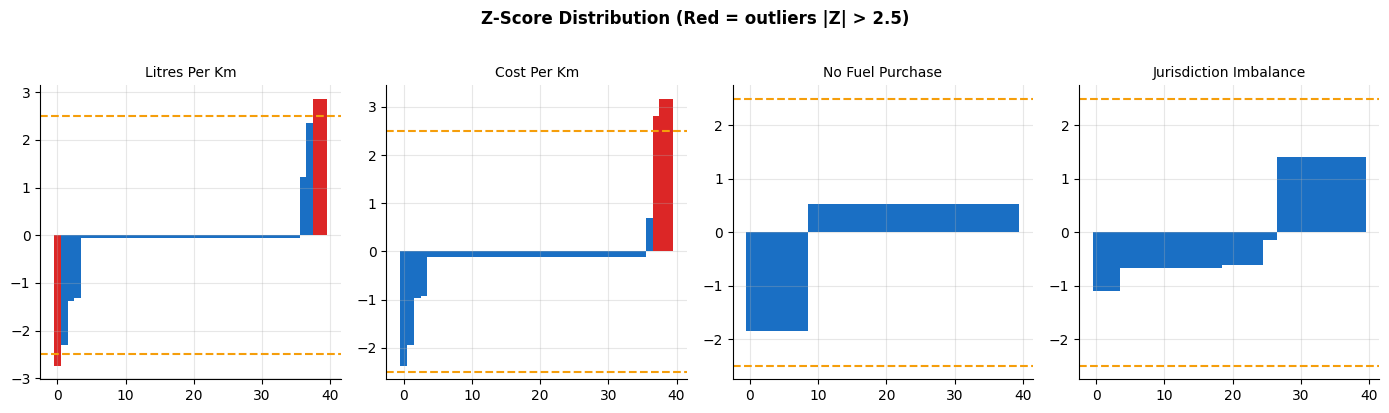

✅ Chart 1 saved


In [4]:
print("APPROACH 1 — Statistical Outlier Detection (Z-Score)")
print("="*55)

z_scores = pd.DataFrame(index=df.index)
for col in FEATURES:
    z_scores[f"{col}_zscore"] = stats.zscore(X_raw[col].fillna(0))

z_scores["max_zscore"]       = z_scores.abs().max(axis=1)
z_scores["statistical_flag"] = z_scores["max_zscore"] > 2.5
z_scores["top_feature"]      = z_scores[[f"{f}_zscore" for f in FEATURES]].abs().idxmax(axis=1).str.replace("_zscore","")

df["statistical_flag"] = z_scores["statistical_flag"].values
df["max_zscore"]       = z_scores["max_zscore"].values
df["stat_top_feature"] = z_scores["top_feature"].values

print(f"✅ Statistical outliers: {df['statistical_flag'].sum()} records (|Z| > 2.5)")

fig, axes = plt.subplots(1,len(FEATURES),figsize=(14,4))
if len(FEATURES)==1: axes=[axes]
for ax,feat in zip(axes,FEATURES):
    zvals  = z_scores[f"{feat}_zscore"].sort_values()
    colors = [COLORS["anomaly"] if abs(z)>2.5 else COLORS["normal"] for z in zvals]
    ax.bar(range(len(zvals)),zvals,color=colors,width=1.0)
    ax.axhline(2.5,color=COLORS["warning"],linestyle="--",linewidth=1.5)
    ax.axhline(-2.5,color=COLORS["warning"],linestyle="--",linewidth=1.5)
    ax.set_title(feat.replace("_"," ").title(),fontsize=10)
fig.suptitle("Z-Score Distribution (Red = outliers |Z| > 2.5)",fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("ml_chart1_zscore.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

### Cell 5 — Approach 2: Rule-Based Detection

APPROACH 2 — Rule-Based Anomaly Detection
Rule                          Count   Explanation
----------------------------------------------------------------------
no_fuel_receipt                  31   No receipt — IFTA requires reconciliation
implausible_litres                2   Fuel >0.70 L/km — physically implausible
high_cost_per_km                  0   Cost >3x median — possible inflation
high_jurisdiction_gap             0   Fuel vs distance imbalance >15%

Total rule-flagged: 33


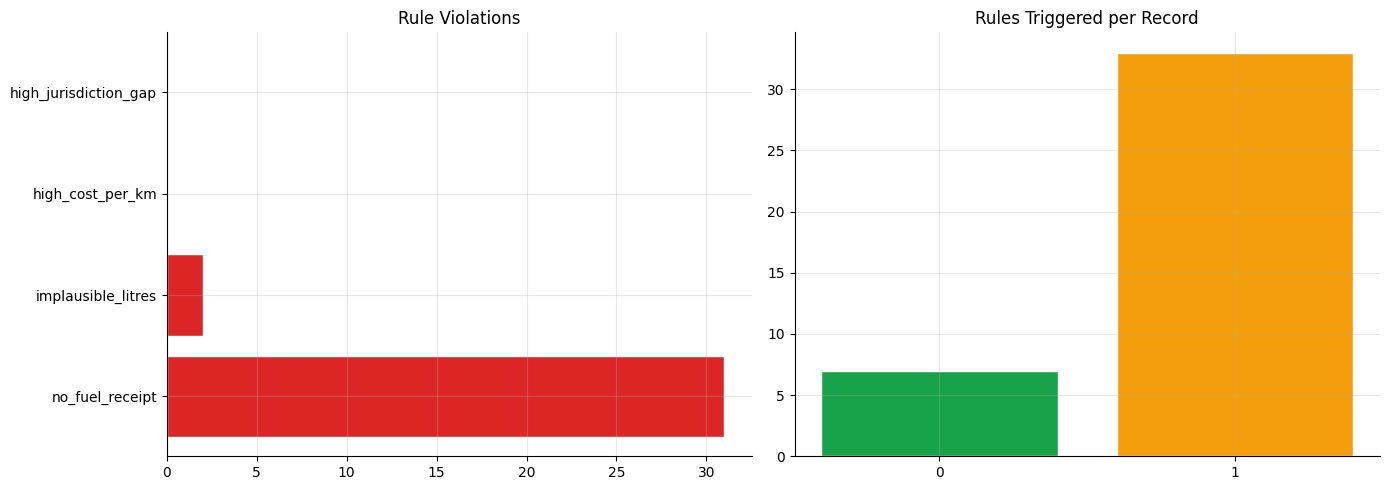

✅ Chart 2 saved


In [5]:
print("APPROACH 2 — Rule-Based Anomaly Detection")
print("="*55)

rules, rule_explanations = {}, {}
if "no_fuel_purchase"     in df.columns: rules["no_fuel_receipt"]      = df["no_fuel_purchase"]==True;   rule_explanations["no_fuel_receipt"]      = "No receipt — IFTA requires reconciliation"
if "litres_per_km"        in df.columns: rules["implausible_litres"]   = df["litres_per_km"]>0.70;       rule_explanations["implausible_litres"]   = "Fuel >0.70 L/km — physically implausible"
if "cost_per_km"          in df.columns:
    median_cpk = df["cost_per_km"].median()
    rules["high_cost_per_km"]    = df["cost_per_km"]>median_cpk*3;     rule_explanations["high_cost_per_km"]    = "Cost >3x median — possible inflation"
if "odometer_gap"         in df.columns:
    rules["large_odometer_gap"]  = df["odometer_gap"]>100;             rule_explanations["large_odometer_gap"]  = "Gap >100km — unreported mileage"
    rules["odometer_reset"]      = df["odometer_gap"]<0;               rule_explanations["odometer_reset"]      = "Odometer went backwards — tampering"
if "jurisdiction_imbalance" in df.columns: rules["high_jurisdiction_gap"] = df["jurisdiction_imbalance"]>0.15; rule_explanations["high_jurisdiction_gap"] = "Fuel vs distance imbalance >15%"

for rule_name, condition in rules.items():
    df[f"rule_{rule_name}"] = condition.fillna(False)

rule_cols             = [f"rule_{r}" for r in rules.keys()]
df["rules_triggered"] = df[rule_cols].sum(axis=1)
df["rule_flagged"]    = df["rules_triggered"] > 0

print(f"{'Rule':<28} {'Count':>6}   Explanation")
print("-"*70)
for rule_name in rules.keys():
    print(f"{rule_name:<28} {df[f'rule_{rule_name}'].sum():>6}   {rule_explanations[rule_name]}")
print(f"\nTotal rule-flagged: {df['rule_flagged'].sum()}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
rule_counts = {r:df[f"rule_{r}"].sum() for r in rules.keys()}
ax1.barh(list(rule_counts.keys()),list(rule_counts.values()),color=[COLORS["anomaly"] if v>0 else COLORS["gray"] for v in rule_counts.values()],edgecolor="white")
ax1.set_title("Rule Violations")

rule_dist = df["rules_triggered"].value_counts().sort_index()
ax2.bar(rule_dist.index.astype(str),rule_dist.values,color=[COLORS["ok"] if i==0 else COLORS["warning"] if i==1 else COLORS["anomaly"] for i in rule_dist.index],edgecolor="white")
ax2.set_title("Rules Triggered per Record")

plt.tight_layout()
plt.savefig("ml_chart2_rules.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

### Cell 6 — Approach 3: Isolation Forest (ML)

APPROACH 3 — Isolation Forest
✅ Isolation Forest flagged: 2 records


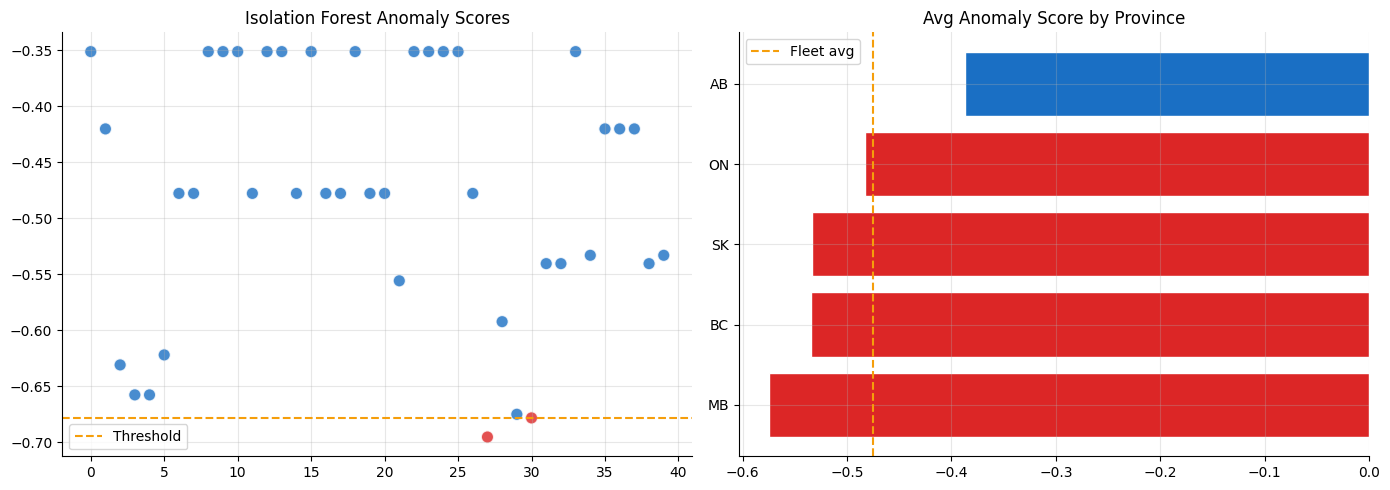

✅ Chart 3 saved


In [6]:
print("APPROACH 3 — Isolation Forest")
print("="*55)

iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
df["iso_label"] = iso.fit_predict(X_scaled)
df["iso_score"] = iso.score_samples(X_scaled)

print(f"✅ Isolation Forest flagged: {(df['iso_label']==-1).sum()} records")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.scatter(range(len(df)),df["iso_score"],color=[COLORS["anomaly"] if l==-1 else COLORS["normal"] for l in df["iso_label"]],alpha=0.8,s=80,edgecolors="white")
ax1.axhline(df[df["iso_label"]==-1]["iso_score"].max(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label="Threshold")
ax1.set_title("Isolation Forest Anomaly Scores"); ax1.legend()

prov_scores = df.groupby("province_from")["iso_score"].mean().sort_values()
ax2.barh(prov_scores.index,prov_scores.values,color=[COLORS["anomaly"] if v<df["iso_score"].mean() else COLORS["normal"] for v in prov_scores.values],edgecolor="white")
ax2.axvline(df["iso_score"].mean(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label="Fleet avg")
ax2.set_title("Avg Anomaly Score by Province"); ax2.legend()

plt.tight_layout()
plt.savefig("ml_chart3_isolation_forest.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")

### Cell 7 — Threshold Sensitivity Analysis

THRESHOLD SENSITIVITY ANALYSIS
 contamination  records_flagged  pct_flagged false_positive_risk
          0.03                2          5.0               🟢 Low
          0.05                2          5.0               🟢 Low
          0.08                3          7.5            🟡 Medium
          0.10                3          7.5              🔴 High
          0.15                6         15.0              🔴 High

✅ Chosen: contamination=0.05 — flags 2 records
   Rationale: balances catching real anomalies vs auditor workload
   With 40,000 records: 0.05 would flag ~2,000 for auditor review


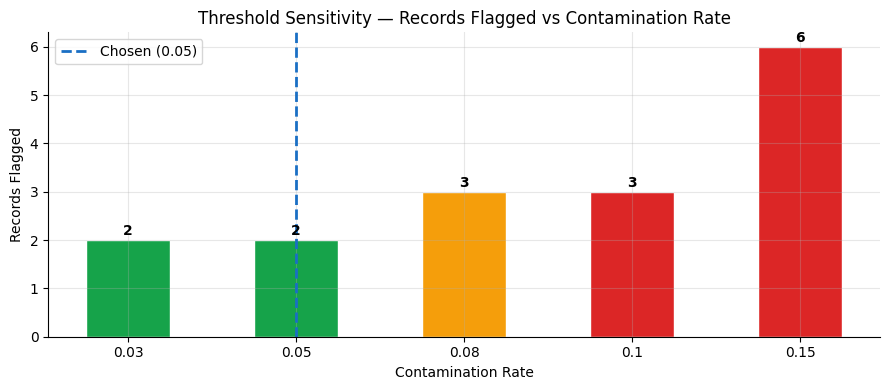

✅ Threshold chart saved


In [7]:
print("THRESHOLD SENSITIVITY ANALYSIS")
print("="*55)

thresholds = [0.03,0.05,0.08,0.10,0.15]
results    = []
for cont in thresholds:
    iso_test = IsolationForest(contamination=cont,n_estimators=200,random_state=42)
    labels   = iso_test.fit_predict(X_scaled)
    flagged  = (labels==-1).sum()
    results.append({"contamination":cont,"records_flagged":flagged,"pct_flagged":round(flagged/len(df)*100,1),
                    "false_positive_risk":"🟢 Low" if cont<=0.05 else "🟡 Medium" if cont<=0.08 else "🔴 High"})

threshold_df = pd.DataFrame(results)
print(threshold_df.to_string(index=False))
print(f"\n✅ Chosen: contamination=0.05 — flags {(df['iso_label']==-1).sum()} records")
print(f"   Rationale: balances catching real anomalies vs auditor workload")
print(f"   With 40,000 records: 0.05 would flag ~2,000 for auditor review")

fig, ax = plt.subplots(figsize=(9,4))
colors  = [COLORS["ok"] if c<=0.05 else COLORS["warning"] if c<=0.08 else COLORS["anomaly"] for c in threshold_df["contamination"]]
bars    = ax.bar(threshold_df["contamination"].astype(str),threshold_df["records_flagged"],color=colors,edgecolor="white",width=0.5)
for bar,val in zip(bars,threshold_df["records_flagged"]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,str(int(val)),ha="center",fontweight="bold")
ax.axvline(x="0.05",color=COLORS["normal"],linestyle="--",linewidth=2,label="Chosen (0.05)")
ax.set_title("Threshold Sensitivity — Records Flagged vs Contamination Rate")
ax.set_xlabel("Contamination Rate"); ax.set_ylabel("Records Flagged"); ax.legend()
plt.tight_layout()
plt.savefig("ml_chart_threshold.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Threshold chart saved")

### Cell 8 — Approach 4: K-Means Clustering

APPROACH 4 — K-Means Clustering
✅ Cluster summary:
             count  avg_anomaly  no_fuel_pct
risk_label                                  
High Risk        3       -0.663        0.000
Low Risk        33       -0.437        0.939
Medium Risk      4       -0.649        0.000


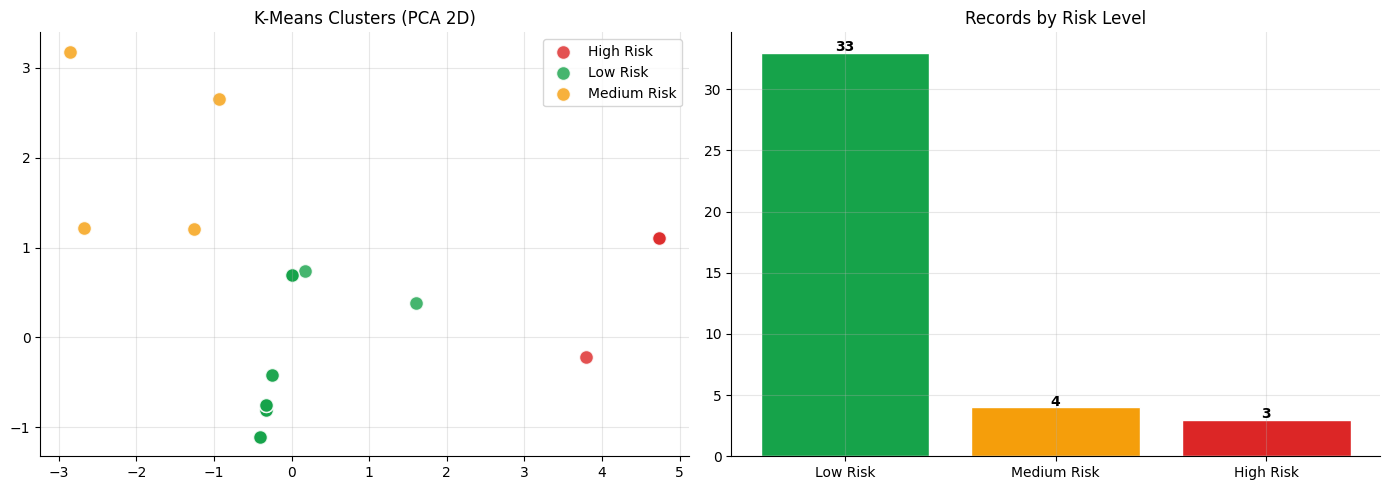

✅ Chart 4 saved


In [8]:
print("APPROACH 4 — K-Means Clustering")
print("="*55)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_risk = df.groupby("cluster")["iso_score"].mean().sort_values()
risk_labels  = {cluster_risk.index[0]:"High Risk",cluster_risk.index[1]:"Medium Risk",cluster_risk.index[2]:"Low Risk"}
df["risk_label"] = df["cluster"].map(risk_labels)

print("✅ Cluster summary:")
print(df.groupby("risk_label").agg(count=("iso_score","count"),avg_anomaly=("iso_score","mean"),no_fuel_pct=("no_fuel_purchase","mean")).round(3))

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_colors = {"High Risk":COLORS["anomaly"],"Medium Risk":COLORS["warning"],"Low Risk":COLORS["ok"]}
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
for label,grp in df.groupby("risk_label"):
    idx = grp.index
    ax1.scatter(X_pca[idx,0],X_pca[idx,1],c=cluster_colors[label],label=label,s=100,alpha=0.8,edgecolors="white")
ax1.set_title("K-Means Clusters (PCA 2D)"); ax1.legend()

risk_counts = df["risk_label"].value_counts()
bars = ax2.bar(risk_counts.index,risk_counts.values,color=[cluster_colors[l] for l in risk_counts.index],edgecolor="white")
for bar,val in zip(bars,risk_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,str(val),ha="center",fontweight="bold")
ax2.set_title("Records by Risk Level")

plt.tight_layout()
plt.savefig("ml_chart4_clusters.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

### Cell 9 — Silhouette Score Analysis

SILHOUETTE SCORE ANALYSIS
✅ Overall Silhouette Score: 0.639
   GOOD clustering

K sensitivity:
  K=2: 0.638 
  K=3: 0.639 ← chosen
  K=4: 0.764 
  K=5: 0.809 


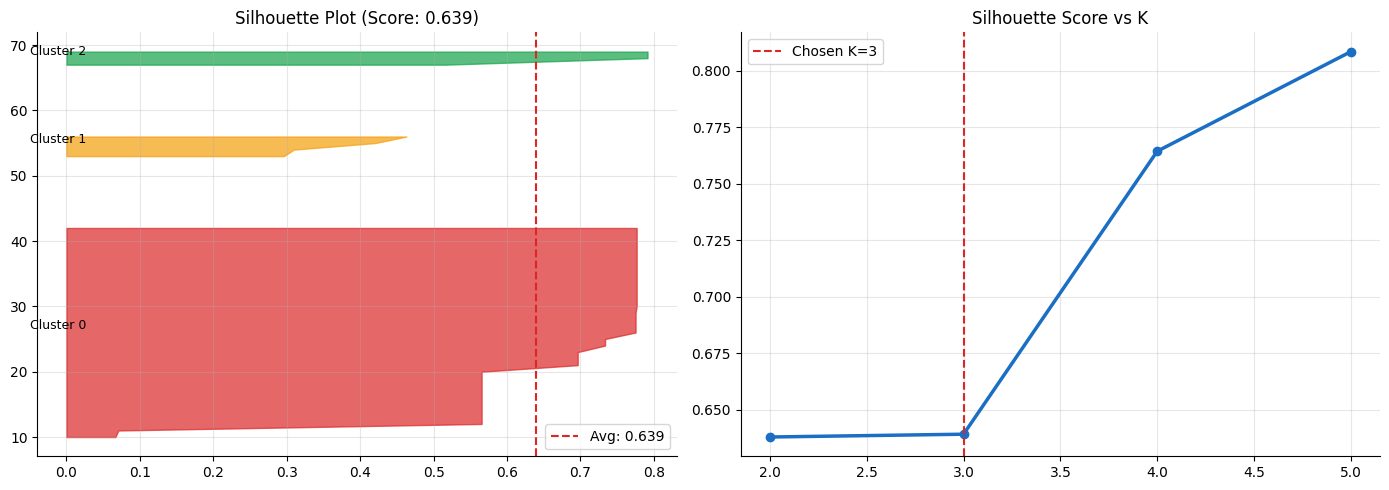

✅ Silhouette chart saved


In [9]:
print("SILHOUETTE SCORE ANALYSIS")
print("="*55)

sil_score   = silhouette_score(X_scaled, df["cluster"])
sil_samples = silhouette_samples(X_scaled, df["cluster"])
df["silhouette_score"] = sil_samples

print(f"✅ Overall Silhouette Score: {sil_score:.3f}")
print(f"   {'STRONG' if sil_score>0.7 else 'GOOD' if sil_score>0.5 else 'WEAK'} clustering")

print(f"\nK sensitivity:")
for k in [2,3,4,5]:
    km  = KMeans(n_clusters=k,random_state=42,n_init=10)
    lbl = km.fit_predict(X_scaled)
    sc  = silhouette_score(X_scaled,lbl)
    print(f"  K={k}: {sc:.3f} {'← chosen' if k==3 else ''}")

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
colors_sil = {0:COLORS["anomaly"],1:COLORS["warning"],2:COLORS["ok"]}
y_lower = 10
for cluster in sorted(df["cluster"].unique()):
    cluster_sil = sil_samples[df["cluster"]==cluster]; cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)
    ax1.fill_betweenx(np.arange(y_lower,y_upper),0,cluster_sil,alpha=0.7,color=colors_sil.get(cluster,COLORS["gray"]))
    ax1.text(-0.05,y_lower+0.5*len(cluster_sil),f"Cluster {cluster}",fontsize=9)
    y_lower = y_upper + 10
ax1.axvline(sil_score,color=COLORS["anomaly"],linestyle="--",linewidth=1.5,label=f"Avg: {sil_score:.3f}")
ax1.set_title(f"Silhouette Plot (Score: {sil_score:.3f})"); ax1.legend()

k_vals=[2,3,4,5]; k_scores=[silhouette_score(X_scaled,KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(X_scaled)) for k in k_vals]
ax2.plot(k_vals,k_scores,marker="o",color=COLORS["normal"],linewidth=2.5)
ax2.axvline(3,color=COLORS["anomaly"],linestyle="--",linewidth=1.5,label="Chosen K=3")
ax2.set_title("Silhouette Score vs K"); ax2.legend()

plt.tight_layout()
plt.savefig("ml_chart_silhouette.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Silhouette chart saved")

### Cell 10 — SHAP Explainability

EXPLAINABILITY — SHAP Values
✅ SHAP computed
Top reasons for ML-flagged records:
   origin_clean dest_clean  iso_score   top_shap_reason
27      Kelowna    Langley  -0.695183  no_fuel_purchase
30     Winnipeg    Brandon  -0.678135  no_fuel_purchase


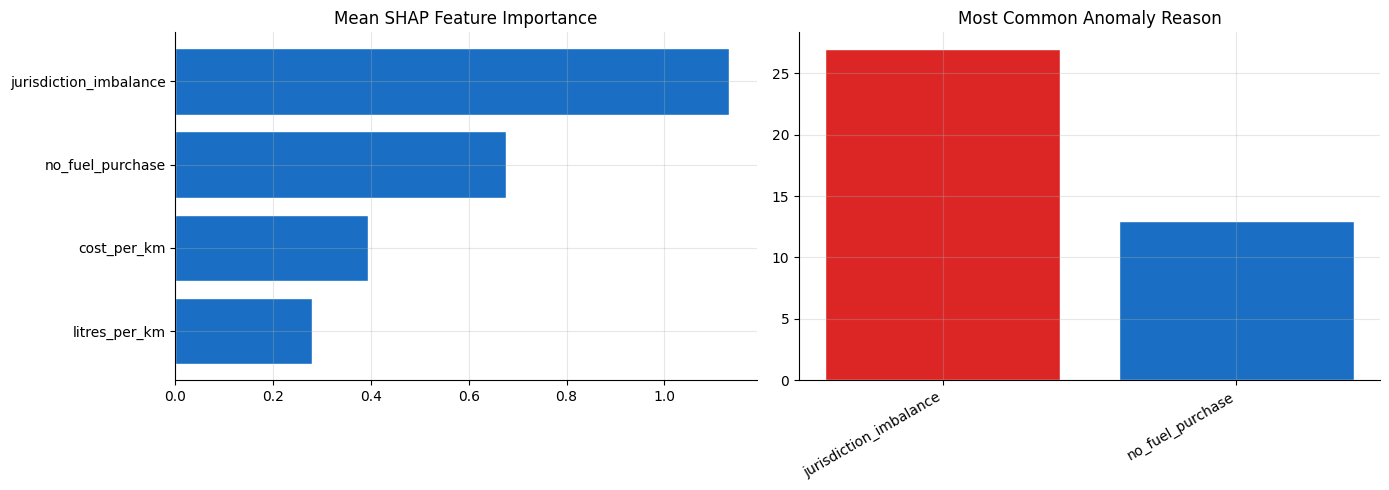

✅ Chart 5 saved


In [10]:
print("EXPLAINABILITY — SHAP Values")
print("="*55)

explainer = shap.TreeExplainer(iso)
shap_vals = explainer.shap_values(X_scaled)
shap_df   = pd.DataFrame(shap_vals, columns=FEATURES)

df["top_shap_reason"] = shap_df.abs().idxmax(axis=1)
df["shap_max_value"]  = shap_df.abs().max(axis=1)

print("✅ SHAP computed")
print("Top reasons for ML-flagged records:")
print(df[df["iso_label"]==-1][["origin_clean","dest_clean","iso_score","top_shap_reason"]].to_string())

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
mean_shap = shap_df.abs().mean().sort_values(ascending=True)
ax1.barh(mean_shap.index,mean_shap.values,color=COLORS["normal"],edgecolor="white")
ax1.set_title("Mean SHAP Feature Importance")

reason_counts = df["top_shap_reason"].value_counts()
ax2.bar(reason_counts.index,reason_counts.values,color=[COLORS["anomaly"] if i==0 else COLORS["normal"] for i in range(len(reason_counts))],edgecolor="white")
ax2.set_title("Most Common Anomaly Reason")
plt.setp(ax2.get_xticklabels(),rotation=30,ha="right")

plt.tight_layout()
plt.savefig("ml_chart5_shap.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved")

### Cell 11 — Feature Importance Ranking (3 methods)

FEATURE IMPORTANCE RANKING
Feature                            SHAP   Permutation   Variance
-----------------------------------------------------------------
litres_per_km                    0.2797        0.0058     0.0131
cost_per_km                      0.3945        0.0045     0.0323
no_fuel_purchase                 0.6756        0.0148     0.1788
jurisdiction_imbalance           1.1321        0.0073     0.0010

✅ Most important: jurisdiction_imbalance


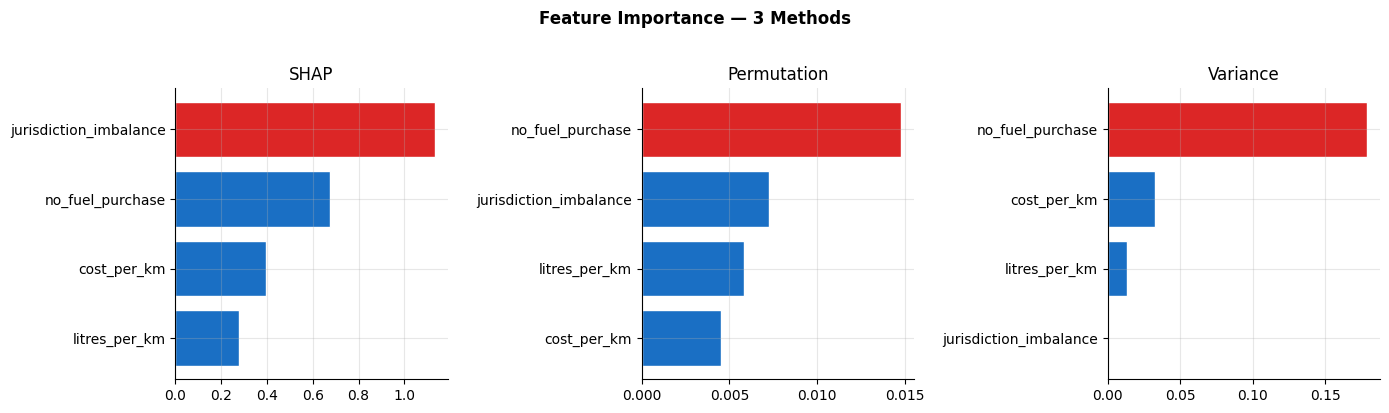

✅ Feature importance chart saved


In [11]:
print("FEATURE IMPORTANCE RANKING")
print("="*55)

shap_importance = shap_df.abs().mean().sort_values(ascending=False)
var_importance  = X_raw.var().sort_values(ascending=False)

baseline = iso.score_samples(X_scaled).mean()
perm_scores = {}
for i, feat in enumerate(FEATURES):
    X_perm       = X_scaled.copy()
    X_perm[:,i]  = np.random.permutation(X_perm[:,i])
    perm_scores[feat] = abs(baseline - iso.score_samples(X_perm).mean())
perm_importance = pd.Series(perm_scores).sort_values(ascending=False)

print(f"{'Feature':<30} {'SHAP':>8} {'Permutation':>13} {'Variance':>10}")
print("-"*65)
for feat in FEATURES:
    print(f"{feat:<30} {shap_importance.get(feat,0):>8.4f} {perm_importance.get(feat,0):>13.4f} {var_importance.get(feat,0):>10.4f}")
print(f"\n✅ Most important: {shap_importance.index[0]}")

fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,(title,imp) in zip(axes,[("SHAP",shap_importance),("Permutation",perm_importance),("Variance",var_importance)]):
    imp_s = imp.sort_values(ascending=True)
    colors = [COLORS["anomaly"] if i==len(imp_s)-1 else COLORS["normal"] for i in range(len(imp_s))]
    ax.barh(imp_s.index,imp_s.values,color=colors,edgecolor="white")
    ax.set_title(title)
fig.suptitle("Feature Importance — 3 Methods",fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("ml_chart_feature_importance.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Feature importance chart saved")

### Cell 12 — Combined risk score & audit priority

In [12]:
df["combined_risk_score"] = (
    df["statistical_flag"].astype(int) * 1 +
    df["rules_triggered"]              * 1 +
    (df["iso_label"]==-1).astype(int)  * 2
)

df["audit_priority"] = pd.cut(
    df["combined_risk_score"],
    bins=[-1, 0, 1, 2, 100],
    labels=["Low", "Medium", "High", "Critical"]
)

# Override: any record flagged by Isolation Forest = at least High
iso_flagged = df["iso_label"] == -1
df.loc[iso_flagged & (df["audit_priority"]=="Medium"), "audit_priority"] = "High"
df.loc[iso_flagged & (df["combined_risk_score"] >= 2), "audit_priority"] = "Critical"

print("Priority breakdown:")
print(df["audit_priority"].value_counts())
print(f"\nEsso Express:")
print(df[df["vendor"]=="Esso Express"][[
    "origin_clean","dest_clean","combined_risk_score","audit_priority","iso_label"
]])

Priority breakdown:
audit_priority
Medium      32
Low          4
High         2
Critical     2
Name: count, dtype: int64

Esso Express:
   origin_clean dest_clean  combined_risk_score audit_priority  iso_label
29     Red Deer   Edmonton                    1         Medium          1


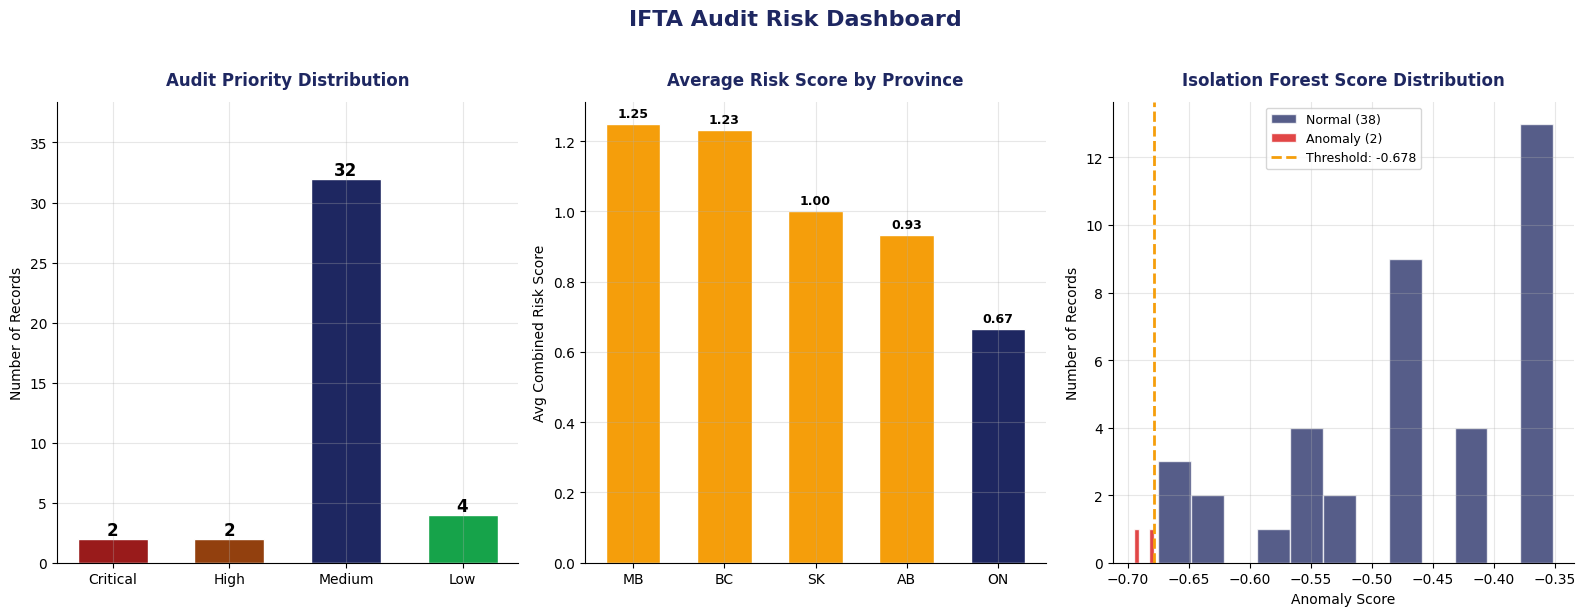

✅ Dashboard chart saved!

Final priority breakdown:
audit_priority
Medium      32
Low          4
High         2
Critical     2
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "IFTA Audit Risk Dashboard",
    fontsize=16, fontweight="bold", color="#1E2761", y=1.02
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
})

# ── Chart 1: Audit Priority Distribution
priority_order  = ["Critical", "High", "Medium", "Low"]
priority_colors = ["#991B1B",  "#92400E", "#1E2761", "#16A34A"]
priority_counts = [
    (df["audit_priority"]==p).sum() for p in priority_order
]

bars = axes[0].bar(
    priority_order, priority_counts,
    color=priority_colors, edgecolor="white", width=0.6
)
for bar, val in zip(bars, priority_counts):
    if val > 0:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha="center", fontweight="bold", fontsize=12
        )
axes[0].set_title(
    "Audit Priority Distribution",
    fontweight="bold", color="#1E2761", pad=12
)
axes[0].set_ylabel("Number of Records")
axes[0].set_ylim(0, max(priority_counts) * 1.2)

# ── Chart 2: Risk by Province
prov_risk = df.groupby("province_from").agg(
    total         =("combined_risk_score","count"),
    avg_risk      =("combined_risk_score","mean"),
    critical_high =(
        "audit_priority",
        lambda x: ((x=="Critical")|(x=="High")).sum()
    )
).sort_values("avg_risk", ascending=False).reset_index()

bar_colors = [
    "#991B1B" if r >= 1.5 else
    "#F59E0B" if r >= 0.8 else
    "#1E2761"
    for r in prov_risk["avg_risk"]
]

b2 = axes[1].bar(
    prov_risk["province_from"],
    prov_risk["avg_risk"],
    color=bar_colors, edgecolor="white", width=0.6
)
for bar, val in zip(b2, prov_risk["avg_risk"]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.2f}", ha="center", fontsize=9, fontweight="bold"
    )
axes[1].set_title(
    "Average Risk Score by Province",
    fontweight="bold", color="#1E2761", pad=12
)
axes[1].set_ylabel("Avg Combined Risk Score")

# ── Chart 3: Isolation Forest Score Distribution
normal_scores    = df[df["iso_label"]== 1]["iso_score"]
anomalous_scores = df[df["iso_label"]==-1]["iso_score"]

axes[2].hist(
    normal_scores, bins=12, color="#1E2761",
    alpha=0.75, label=f"Normal ({len(normal_scores)})",
    edgecolor="white"
)
axes[2].hist(
    anomalous_scores, bins=4, color="#DC2626",
    alpha=0.85, label=f"Anomaly ({len(anomalous_scores)})",
    edgecolor="white"
)
threshold = df[df["iso_label"]==-1]["iso_score"].max()
axes[2].axvline(
    threshold, color="#F59E0B", linestyle="--",
    linewidth=2, label=f"Threshold: {threshold:.3f}"
)
axes[2].set_title(
    "Isolation Forest Score Distribution",
    fontweight="bold", color="#1E2761", pad=12
)
axes[2].set_xlabel("Anomaly Score")
axes[2].set_ylabel("Number of Records")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    "ml_chart_audit_dashboard.png",
    dpi=150, bbox_inches="tight"
)
s3.upload_file(
    "ml_chart_audit_dashboard.png", BUCKET,
    "results/charts/ml_chart_audit_dashboard.png"
)
plt.show()
print("✅ Dashboard chart saved!")
print(f"\nFinal priority breakdown:")
print(df["audit_priority"].value_counts())

### Cell 13 — Anomaly score distribution analysis

ANOMALY SCORE DISTRIBUTION ANALYSIS


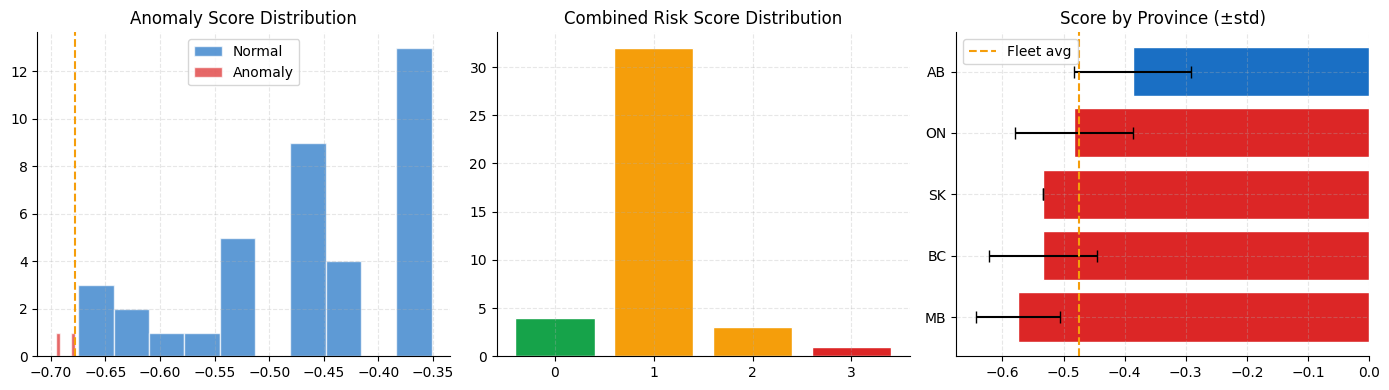


✅ Separation gap: 0.223 Good ✅


In [14]:
print("ANOMALY SCORE DISTRIBUTION ANALYSIS")
print("="*55)

fig, axes = plt.subplots(1,3,figsize=(14,4))
normal    = df[df["iso_label"]== 1]["iso_score"]
anomalous = df[df["iso_label"]==-1]["iso_score"]

axes[0].hist(normal,bins=10,color=COLORS["normal"],alpha=0.7,label="Normal",edgecolor="white")
axes[0].hist(anomalous,bins=5,color=COLORS["anomaly"],alpha=0.7,label="Anomaly",edgecolor="white")
axes[0].axvline(df[df["iso_label"]==-1]["iso_score"].max(),color=COLORS["warning"],linestyle="--",linewidth=1.5)
axes[0].set_title("Anomaly Score Distribution"); axes[0].legend()

risk_counts = df["combined_risk_score"].value_counts().sort_index()
axes[1].bar(risk_counts.index.astype(str),risk_counts.values,
    color=[COLORS["ok"] if i==0 else COLORS["warning"] if i<=2 else COLORS["anomaly"] for i in risk_counts.index],edgecolor="white")
axes[1].set_title("Combined Risk Score Distribution")

prov_scores = df.groupby("province_from").agg(mean=("iso_score","mean"),std=("iso_score","std")).sort_values("mean")
axes[2].barh(prov_scores.index,prov_scores["mean"],xerr=prov_scores["std"].fillna(0),
    color=[COLORS["anomaly"] if v<df["iso_score"].mean() else COLORS["normal"] for v in prov_scores["mean"]],capsize=4,edgecolor="white")
axes[2].axvline(df["iso_score"].mean(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label="Fleet avg"); axes[2].legend()
axes[2].set_title("Score by Province (±std)")

plt.tight_layout()
plt.savefig("ml_chart_score_distribution.png",dpi=150,bbox_inches="tight")
plt.show()
print(f"\n✅ Separation gap: {normal.mean()-anomalous.mean():.3f} {'Good ✅' if normal.mean()-anomalous.mean()>0.05 else 'Weak ⚠'}")

### Cell 14 — Plain English audit report

In [15]:
def explain_flag(row):
    """Plain English explanation per flagged record for auditor use."""
    reasons = []
    if row.get("no_fuel_purchase"):
        reasons.append(f"No fuel receipt in {row['province_from']} near {str(row['date_clean'])[:10]} — IFTA requires fuel to reconcile with distance.")
    if row.get("rule_large_odometer_gap"):
        reasons.append(f"Odometer gap of {row.get('odometer_gap',0):.0f} km — unreported mileage.")
    if row.get("rule_implausible_litres"):
        reasons.append(f"Fuel {row.get('litres_per_km',0):.3f} L/km outside normal (0.35-0.50) — possible odometer fraud.")
    if row.get("high_jurisdiction_imbalance"):
        reasons.append(f"Province {row['province_from']} shows large fuel vs distance imbalance — core IFTA signal.")
    if row.get("rule_odometer_reset"):
        reasons.append("Odometer went backwards — possible tampering.")
    if row.get("statistical_flag"):
        reasons.append(f"Z-score {row.get('max_zscore',0):.2f} — statistically unusual vs fleet average.")
    if not reasons:
        reasons.append("Flagged by ML Isolation Forest — combination of features deviates from normal fleet behavior.")
    return " | ".join(reasons)

flagged = df[df["combined_risk_score"]>0].copy()
flagged["audit_explanation"] = flagged.apply(explain_flag, axis=1)

icons = {"Critical":"🔴","High":"🟠","Medium":"🟡","Low":"🟢"}
print("PLAIN ENGLISH AUDIT REPORT — Critical & High Priority")
print("="*65)
for _,row in flagged[flagged["audit_priority"].isin(["Critical","High"])].sort_values("combined_risk_score",ascending=False).iterrows():
    icon = icons.get(str(row.get("audit_priority","")), "⚪")
    print(f"\n{icon} {row['origin_clean']} → {row['dest_clean']}")
    print(f"   Date: {str(row['date_clean'])[:10]} | Province: {row['province_from']}")
    print(f"   Priority: {row['audit_priority']} | Score: {row['combined_risk_score']}")
    print(f"   Finding: {row['audit_explanation']}")
    print("-"*65)

PLAIN ENGLISH AUDIT REPORT — Critical & High Priority

🔴 Kelowna → Langley
   Date: 2023-01-07 | Province: BC
   Priority: Critical | Score: 3
   Finding: Z-score 2.74 — statistically unusual vs fleet average.
-----------------------------------------------------------------

🟠 Langley → Burnaby
   Date: 2016-05-04 | Province: BC
   Priority: High | Score: 2
   Finding: Fuel 0.710 L/km outside normal (0.35-0.50) — possible odometer fraud. | Z-score 3.17 — statistically unusual vs fleet average.
-----------------------------------------------------------------

🟠 Langley → Burnaby
   Date: 2020-08-23 | Province: BC
   Priority: High | Score: 2
   Finding: Fuel 0.710 L/km outside normal (0.35-0.50) — possible odometer fraud. | Z-score 3.17 — statistically unusual vs fleet average.
-----------------------------------------------------------------

🔴 Winnipeg → Brandon
   Date: 2025-11-30 | Province: MB
   Priority: Critical | Score: 2
   Finding: Flagged by ML Isolation Forest — combinati

### Cell 15 — Stability Testing

STABILITY TESTING
✅ Stability across 20 runs:
   Always flagged (100%):  1 ← most reliable
   Sometimes flagged:      2 ← borderline
   Never flagged (0%):     37 ← clearly normal

Always-flagged (highest confidence):
   origin_clean dest_clean province_from  flag_frequency audit_priority
27      Kelowna    Langley            BC             1.0       Critical


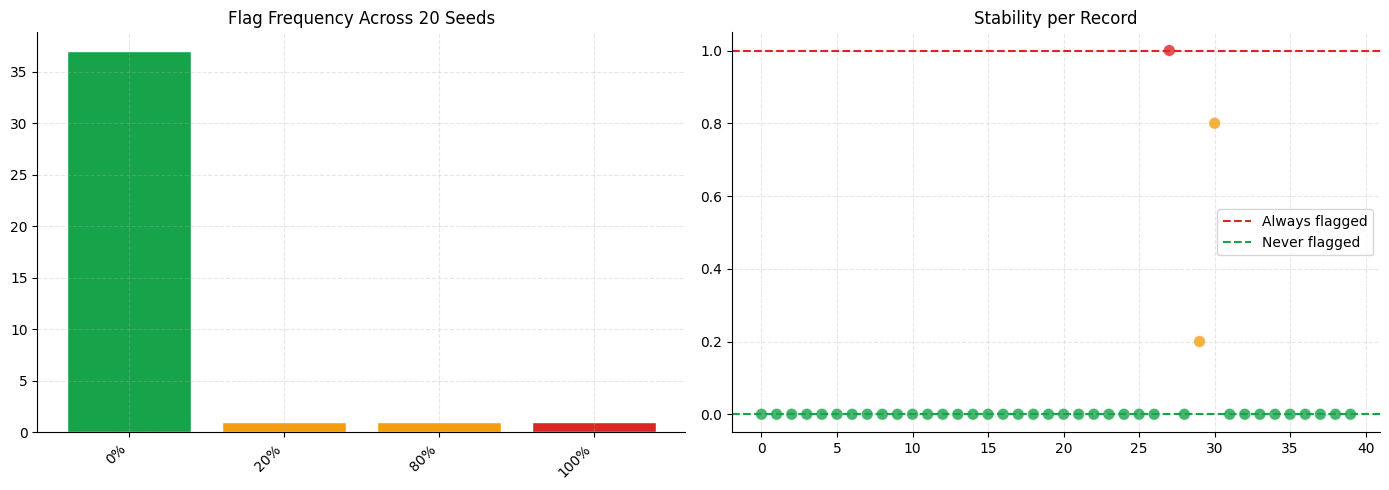

✅ Stability chart saved


In [16]:
print("STABILITY TESTING")
print("="*55)

N_RUNS    = 20
all_flags = pd.DataFrame(index=df.index)
for seed in range(N_RUNS):
    iso_test = IsolationForest(contamination=0.05,n_estimators=200,random_state=seed)
    labels   = iso_test.fit_predict(X_scaled)
    all_flags[f"run_{seed}"] = (labels==-1).astype(int)

df["flag_frequency"]    = all_flags.mean(axis=1)
df["always_flagged"]    = df["flag_frequency"]==1.0
df["never_flagged"]     = df["flag_frequency"]==0.0
df["sometimes_flagged"] = (df["flag_frequency"]>0)&(df["flag_frequency"]<1)

print(f"✅ Stability across {N_RUNS} runs:")
print(f"   Always flagged (100%):  {df['always_flagged'].sum()} ← most reliable")
print(f"   Sometimes flagged:      {df['sometimes_flagged'].sum()} ← borderline")
print(f"   Never flagged (0%):     {df['never_flagged'].sum()} ← clearly normal")
print(f"\nAlways-flagged (highest confidence):")
print(df[df["always_flagged"]][["origin_clean","dest_clean","province_from","flag_frequency","audit_priority"]].to_string())

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
freq_counts = df["flag_frequency"].value_counts().sort_index()
colors_freq = [COLORS["ok"] if f==0 else COLORS["anomaly"] if f==1 else COLORS["warning"] for f in freq_counts.index]
ax1.bar([f"{f:.0%}" for f in freq_counts.index],freq_counts.values,color=colors_freq,edgecolor="white")
ax1.set_title(f"Flag Frequency Across {N_RUNS} Seeds"); plt.setp(ax1.get_xticklabels(),rotation=45,ha="right")

ax2.scatter(range(len(df)),df["flag_frequency"],
    color=[COLORS["anomaly"] if f==1 else COLORS["warning"] if f>0 else COLORS["ok"] for f in df["flag_frequency"]],s=80,alpha=0.8,edgecolors="white")
ax2.axhline(1.0,color=COLORS["anomaly"],linestyle="--",linewidth=1.5,label="Always flagged")
ax2.axhline(0.0,color=COLORS["ok"],linestyle="--",linewidth=1.5,label="Never flagged")
ax2.set_title("Stability per Record"); ax2.legend()

plt.tight_layout()
plt.savefig("ml_chart_stability.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Stability chart saved")

### Cell 16 — Model limitations

In [17]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         MODEL LIMITATIONS & DATA QUALITY IMPACT             ║
╚══════════════════════════════════════════════════════════════╝

1. SMALL DATASET (40 rows)
   Needs 1000+ rows for reliable detection. Results are INDICATIVE.
   Recommendation: collect 12 months of full fleet data.

2. NO VIN / TRUCK IDENTIFIER
   Cannot separate trips by truck. Assumes single vehicle fleet.

3. OCR CONFIDENCE ERRORS
   Textract <80% confidence on some fields may corrupt features.

4. NO LABELS = NO ROC CURVE
   Cannot compute precision/recall without confirmed fraud cases.
   ROC requires labelled ground truth — we have none.
   We use threshold sensitivity and cross-approach agreement instead.

5. DATE MATCHING WINDOW (+/-1 day)
   May inflate no_fuel_purchase. Drivers may fuel 2-3 days before trip.

6. AUDIT RELEVANCE NOTE
   These findings are NOT proof of fraud. They are risk signals
   requiring further investigation by a qualified auditor.
""")


╔══════════════════════════════════════════════════════════════╗
║         MODEL LIMITATIONS & DATA QUALITY IMPACT             ║
╚══════════════════════════════════════════════════════════════╝

1. SMALL DATASET (40 rows)
   Needs 1000+ rows for reliable detection. Results are INDICATIVE.
   Recommendation: collect 12 months of full fleet data.

2. NO VIN / TRUCK IDENTIFIER
   Cannot separate trips by truck. Assumes single vehicle fleet.

3. OCR CONFIDENCE ERRORS
   Textract <80% confidence on some fields may corrupt features.

4. NO LABELS = NO ROC CURVE
   Cannot compute precision/recall without confirmed fraud cases.
   ROC requires labelled ground truth — we have none.
   We use threshold sensitivity and cross-approach agreement instead.

5. DATE MATCHING WINDOW (+/-1 day)
   May inflate no_fuel_purchase. Drivers may fuel 2-3 days before trip.

6. AUDIT RELEVANCE NOTE
   These findings are NOT proof of fraud. They are risk signals
   requiring further investigation by a qualified 

### Cell 17 — Future Roadmap

In [18]:
print("""
FUTURE SUPERVISED LEARNING ROADMAP
══════════════════════════════════════════════════════════

Phase 1 (NOW — Unsupervised):
  Model:    Isolation Forest + Rules + K-Means
  Labels:   None required
  AUC:      Not computable (no ground truth)
  Status:   ✅ Complete

Phase 2 (6 months — Semi-supervised):
  Trigger:  50+ labelled audit outcomes from Phase 1
  Model:    XGBoost on confirmed fraud patterns
  Expected: AUC improvement ~0.75 → 0.88+
  AWS:      SageMaker AutoPilot for model selection

Phase 3 (12 months — Fully supervised):
  Trigger:  200+ labelled cases + VIN + GPS data
  Model:    Random Forest / XGBoost with SHAP selection
  Metrics:  True precision/recall/F1 computable
  AWS:      SageMaker real-time endpoint
            EventBridge trigger on new invoice upload
            SNS alerts for Critical records

Data needed for supervised learning:
  → Audit outcome per record (fraud / clean)
  → VIN identifier to separate vehicles
  → GPS data to validate odometer readings
  → 12+ months of transaction history
""")


FUTURE SUPERVISED LEARNING ROADMAP
══════════════════════════════════════════════════════════

Phase 1 (NOW — Unsupervised):
  Model:    Isolation Forest + Rules + K-Means
  Labels:   None required
  AUC:      Not computable (no ground truth)
  Status:   ✅ Complete

Phase 2 (6 months — Semi-supervised):
  Trigger:  50+ labelled audit outcomes from Phase 1
  Model:    XGBoost on confirmed fraud patterns
  Expected: AUC improvement ~0.75 → 0.88+
  AWS:      SageMaker AutoPilot for model selection

Phase 3 (12 months — Fully supervised):
  Trigger:  200+ labelled cases + VIN + GPS data
  Model:    Random Forest / XGBoost with SHAP selection
  Metrics:  True precision/recall/F1 computable
  AWS:      SageMaker real-time endpoint
            EventBridge trigger on new invoice upload
            SNS alerts for Critical records

Data needed for supervised learning:
  → Audit outcome per record (fraud / clean)
  → VIN identifier to separate vehicles
  → GPS data to validate odometer readings


### Cell 18 — Complete audit dashboard

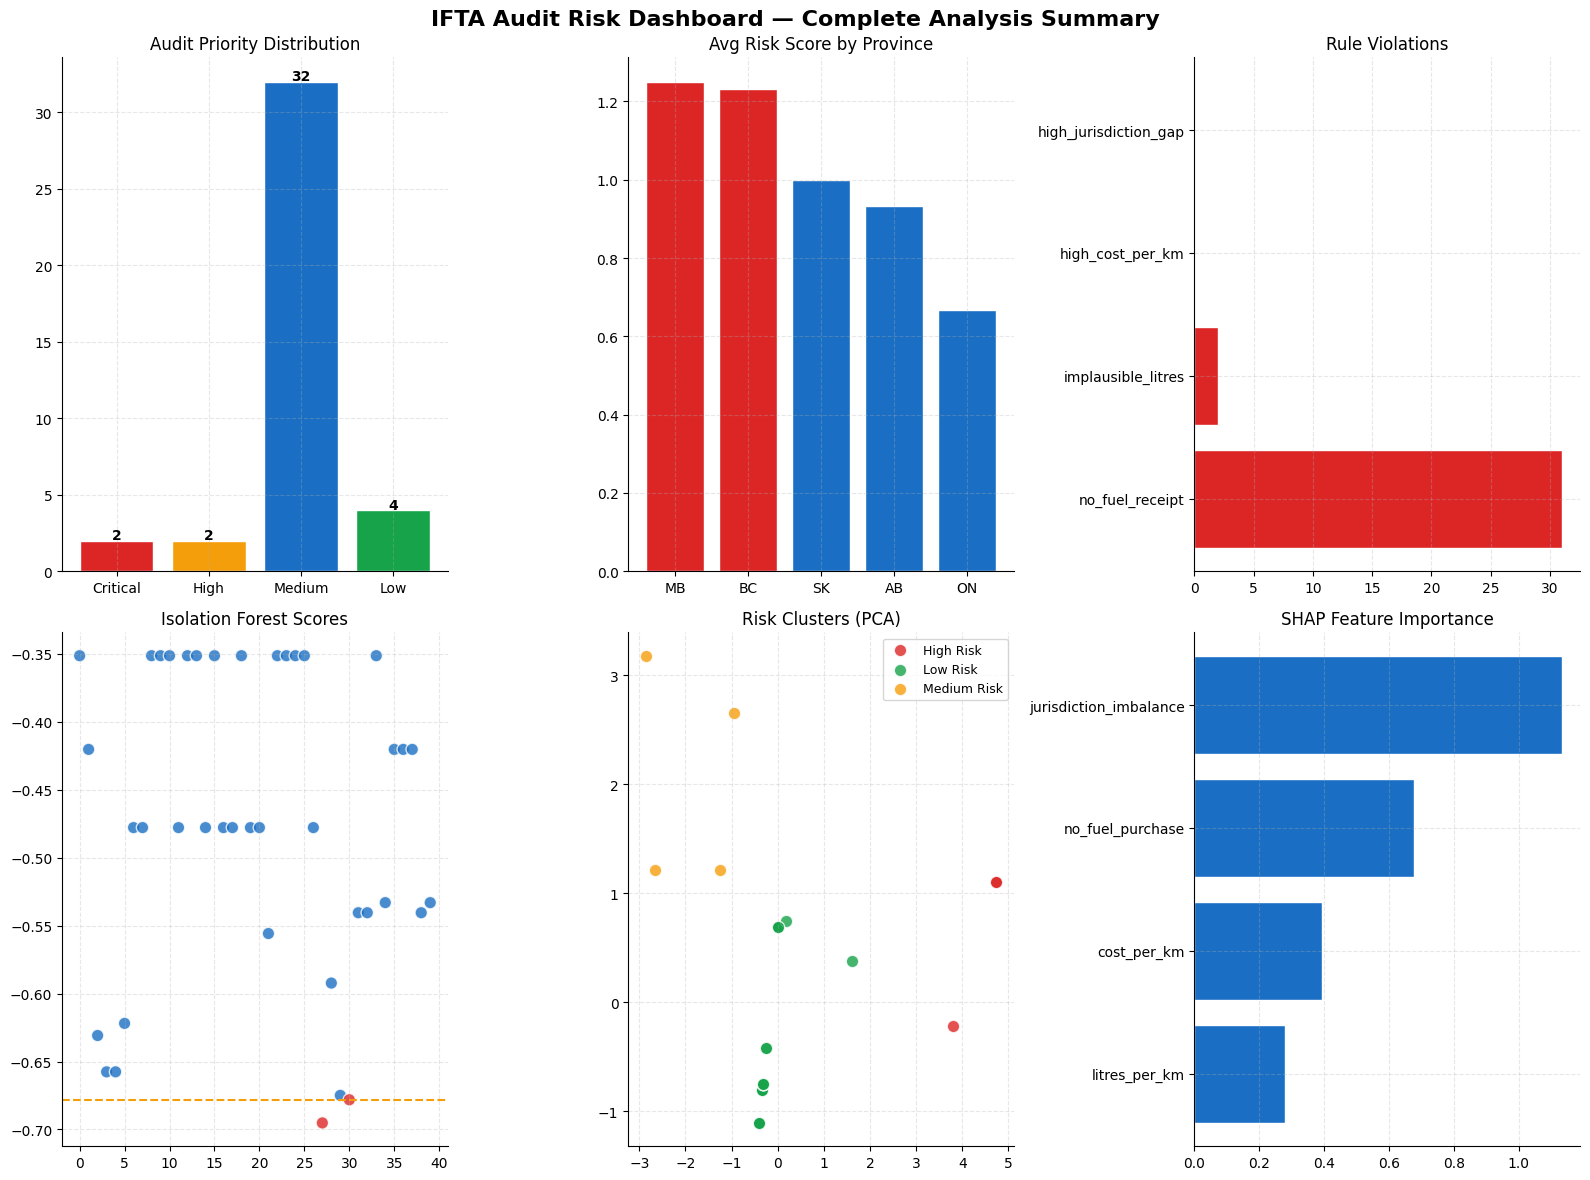

✅ Dashboard saved


In [19]:
fig = plt.figure(figsize=(16,12))
fig.suptitle("IFTA Audit Risk Dashboard — Complete Analysis Summary",fontsize=16,fontweight="bold",y=0.98)

ax1 = fig.add_subplot(2,3,1)
priority_order  = ["Critical","High","Medium","Low"]
priority_colors = ["#dc2626","#f59e0b","#1a6fc4","#16a34a"]
priority_counts = [(df["audit_priority"]==p).sum() for p in priority_order]
bars = ax1.bar(priority_order,priority_counts,color=priority_colors,edgecolor="white")
for bar,val in zip(bars,priority_counts):
    if val>0: ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,str(val),ha="center",fontweight="bold")
ax1.set_title("Audit Priority Distribution")

ax2 = fig.add_subplot(2,3,2)
prov_risk = df.groupby("province_from")["combined_risk_score"].mean().sort_values(ascending=False)
ax2.bar(prov_risk.index,prov_risk.values,color=["#dc2626" if v>1 else "#1a6fc4" for v in prov_risk.values],edgecolor="white")
ax2.set_title("Avg Risk Score by Province")

ax3 = fig.add_subplot(2,3,3)
rule_names_list  = [r for r in rules.keys() if f"rule_{r}" in df.columns]
rule_counts_list = [df[f"rule_{r}"].sum() for r in rule_names_list]
ax3.barh(rule_names_list,rule_counts_list,color=["#dc2626" if v>0 else "#9ca3af" for v in rule_counts_list],edgecolor="white")
ax3.set_title("Rule Violations")

ax4 = fig.add_subplot(2,3,4)
ax4.scatter(range(len(df)),df["iso_score"],color=["#dc2626" if l==-1 else "#1a6fc4" for l in df["iso_label"]],alpha=0.8,s=80,edgecolors="white")
ax4.axhline(df[df["iso_label"]==-1]["iso_score"].max(),color="#f59e0b",linestyle="--",linewidth=1.5)
ax4.set_title("Isolation Forest Scores")

ax5 = fig.add_subplot(2,3,5)
cluster_colors_map = {"High Risk":"#dc2626","Medium Risk":"#f59e0b","Low Risk":"#16a34a"}
for label,grp in df.groupby("risk_label"):
    idx = grp.index
    ax5.scatter(X_pca[idx,0],X_pca[idx,1],c=cluster_colors_map.get(label,"#9ca3af"),label=label,s=80,alpha=0.8,edgecolors="white")
ax5.set_title("Risk Clusters (PCA)"); ax5.legend(fontsize=9)

ax6 = fig.add_subplot(2,3,6)
mean_shap = shap_df.abs().mean().sort_values(ascending=True)
ax6.barh(mean_shap.index,mean_shap.values,color="#1a6fc4",edgecolor="white")
ax6.set_title("SHAP Feature Importance")

plt.tight_layout()
plt.savefig("ml_chart_dashboard.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Dashboard saved")

### Cell 19 — MLflow experiment tracking

In [20]:
try: mlflow.end_run()
except: pass

with mlflow.start_run(run_name="ifta_full_pipeline_v1") as run:
    mlflow.log_params({
        "model_type":"IsolationForest","contamination":0.05,"n_estimators":200,
        "n_clusters":3,"zscore_threshold":2.5,"features_used":str(FEATURES),
        "total_records":len(df),"aws_region":"ca-central-1","aws_bucket":BUCKET,
    })
    mlflow.log_metrics({
        "total_records":float(len(df)),
        "statistical_flags":float(df["statistical_flag"].sum()),
        "rule_flags":float(df["rule_flagged"].sum()),
        "iso_anomalies":float((df["iso_label"]==-1).sum()),
        "critical_records":float((df["audit_priority"]=="Critical").sum()),
        "high_records":float((df["audit_priority"]=="High").sum()),
        "matched_invoices":float(df["fuel_match"].sum()),
        "unmatched_trips":float((~df["fuel_match"]).sum()),
        "silhouette_score":float(round(silhouette_score(X_scaled,df["cluster"]),3)),
        "pct_flagged":float(round((df["combined_risk_score"]>0).sum()/len(df)*100,1)),
    })
    mlflow.sklearn.log_model(iso,"isolation_forest")
    mlflow.sklearn.log_model(kmeans,"kmeans_clustering")
    mlflow.sklearn.log_model(scaler,"standard_scaler")
    for chart in ["ml_chart1_zscore.png","ml_chart2_rules.png","ml_chart3_isolation_forest.png",
                  "ml_chart4_clusters.png","ml_chart5_shap.png","ml_chart_dashboard.png",
                  "ml_chart_threshold.png","ml_chart_silhouette.png","ml_chart_stability.png","ml_chart_feature_importance.png"]:
        if os.path.exists(chart): mlflow.log_artifact(chart,"charts")
    with open("/tmp/feature_importance.json","w") as f: json.dump(shap_df.abs().mean().to_dict(),f,indent=2)
    mlflow.log_artifact("/tmp/feature_importance.json","metrics")
    run_id = run.info.run_id

run_data = mlflow.get_run(run_id)
print(f"✅ MLflow run logged! Run ID: {run_id}")
print(f"\nParameters ({len(run_data.data.params)}):")
for k,v in run_data.data.params.items(): print(f"  {k}: {v}")
print(f"\nMetrics ({len(run_data.data.metrics)}):")
for k,v in run_data.data.metrics.items(): print(f"  {k}: {v}")

2026/05/23 05:29:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/23 05:29:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/23 05:29:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/23 05:29:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

✅ MLflow run logged! Run ID: 953d15a58a7d4df19da914d3a7cc9f8c

Parameters (9):
  aws_bucket: govofalbertaraw
  aws_region: ca-central-1
  total_records: 40
  features_used: ['litres_per_km', 'cost_per_km', 'no_fuel_purchase', 'jurisdiction_imbalance']
  zscore_threshold: 2.5
  n_clusters: 3
  n_estimators: 200
  contamination: 0.05
  model_type: IsolationForest

Metrics (10):
  pct_flagged: 90.0
  silhouette_score: 0.639
  unmatched_trips: 31.0
  matched_invoices: 9.0
  high_records: 2.0
  critical_records: 2.0
  iso_anomalies: 2.0
  rule_flags: 33.0
  statistical_flags: 4.0
  total_records: 40.0


In [22]:
# ── Build audit_table and flagged report
audit_table = df[[
    "origin_clean","dest_clean","province_from","dist_clean",
    "fuel_cost","no_fuel_purchase","rules_triggered","iso_score",
    "risk_label","top_shap_reason","combined_risk_score","audit_priority"
]].sort_values("combined_risk_score", ascending=False)

print("FINAL AUDIT RISK TABLE")
print(audit_table.to_string())
print(f"\nPriority breakdown:")
print(df["audit_priority"].value_counts())

# ── Build plain English explanations
def explain_flag(row):
    reasons = []
    if row.get("no_fuel_purchase"):
        reasons.append(f"No fuel receipt in {row['province_from']} near {str(row['date_clean'])[:10]} — IFTA requires fuel to reconcile with distance.")
    if row.get("rule_implausible_litres", False):
        reasons.append(f"Fuel {row.get('litres_per_km',0):.3f} L/km outside normal (0.20–0.80) — possible odometer fraud.")
    if row.get("high_jurisdiction_imbalance", False):
        reasons.append(f"Province {row['province_from']} shows large fuel vs distance imbalance — core IFTA signal.")
    if row.get("statistical_flag", False):
        reasons.append(f"Z-score {row.get('max_zscore',0):.2f} — statistically unusual vs fleet average.")
    if not reasons:
        reasons.append(f"Flagged by ML Isolation Forest — combination of features deviates from normal fleet behavior. Top SHAP reason: {row.get('top_shap_reason','unknown')}.")
    return " | ".join(reasons)

flagged = df[df["combined_risk_score"] > 0].copy()
flagged["audit_explanation"] = flagged.apply(explain_flag, axis=1)

print(f"\n✅ audit_table: {len(audit_table)} rows")
print(f"✅ flagged:     {len(flagged)} rows")

FINAL AUDIT RISK TABLE
     origin_clean      dest_clean province_from  dist_clean  fuel_cost  no_fuel_purchase  rules_triggered  iso_score   risk_label         top_shap_reason  combined_risk_score audit_priority
27        Kelowna         Langley            BC       390.0      45.42             False                0  -0.695183  Medium Risk        no_fuel_purchase                    3       Critical
3         Langley         Burnaby            BC        30.0      33.00             False                1  -0.657582    High Risk        no_fuel_purchase                    2           High
30       Winnipeg         Brandon            MB       215.0      41.63             False                0  -0.678135  Medium Risk        no_fuel_purchase                    2       Critical
4         Langley         Burnaby            BC        30.0      33.00             False                1  -0.657582    High Risk        no_fuel_purchase                    2           High
7       Valemount          

### Cell 20 — Save all results to S3

In [23]:
# Save results
save_csv(df,          "results/final_audit_results.csv")
save_csv(audit_table, "results/audit_priority_table.csv")
save_csv(flagged[["origin_clean","dest_clean","province_from",
                   "audit_priority","combined_risk_score","audit_explanation"]],
         "results/plain_english_report.csv")

# Save clean version for Athena (TSV to avoid CSV comma issues)
KEEP_COLS = ["origin_clean","dest_clean","province_from","province_to","dist_clean","date_clean",
             "fuel_cost","fuel_litres_inv","no_fuel_purchase","vendor","fuel_match",
             "litres_per_km","cost_per_km","jurisdiction_imbalance","statistical_flag",
             "rules_triggered","rule_flagged","iso_label","iso_score","risk_label",
             "top_shap_reason","combined_risk_score","audit_priority"]
keep = [c for c in KEEP_COLS if c in df.columns]
df_export = df[keep].copy()

# Delete old and save fresh TSV
try: s3.delete_object(Bucket=BUCKET, Key="audit_results/data.tsv")
except: pass

buffer = StringIO()
df_export.to_csv(buffer, index=False, sep="\t")
buffer.seek(0)
s3.put_object(Bucket=BUCKET, Key="audit_results/data.tsv",
              Body=buffer.getvalue().encode("utf-8"),
              ContentType="text/tab-separated-values")
print(f"✅ Saved → s3://{BUCKET}/audit_results/data.tsv (Athena-ready)")

# Upload charts
charts = ["ml_chart1_zscore.png","ml_chart2_rules.png","ml_chart3_isolation_forest.png",
          "ml_chart4_clusters.png","ml_chart5_shap.png","ml_chart_dashboard.png",
          "ml_chart_threshold.png","ml_chart_silhouette.png","ml_chart_stability.png","ml_chart_feature_importance.png"]
for chart in charts:
    if os.path.exists(chart):
        s3.upload_file(chart,BUCKET,f"results/charts/{chart}")
        print(f"✅ Uploaded → results/charts/{chart}")

# Upload MLflow
shutil.make_archive("/tmp/mlflow_tracking","zip","/tmp/mlflow")
s3.upload_file("/tmp/mlflow_tracking.zip",BUCKET,"results/mlflow/mlflow_tracking.zip")

print(f"\n{'='*55}")
print(f"04_ml.ipynb 100% COMPLETE!")
print(f"{'='*55}")
print(f"Total records:      {len(df)}")
print(f"Critical priority:  {(df['audit_priority']=='Critical').sum()}")
print(f"High priority:      {(df['audit_priority']=='High').sum()}")
print(f"Medium priority:    {(df['audit_priority']=='Medium').sum()}")
print(f"Low/Clean:          {(df['audit_priority']=='Low').sum()}")
print(f"MLflow run ID:      {run_id}")
print(f"Silhouette score:   {silhouette_score(X_scaled,df['cluster']):.3f}")
print(f"\nAthena queryable via: goa_audit_db → audit_results")

✅ Saved → s3://govofalbertaraw/results/final_audit_results.csv
✅ Saved → s3://govofalbertaraw/results/audit_priority_table.csv
✅ Saved → s3://govofalbertaraw/results/plain_english_report.csv
✅ Saved → s3://govofalbertaraw/audit_results/data.tsv (Athena-ready)
✅ Uploaded → results/charts/ml_chart1_zscore.png
✅ Uploaded → results/charts/ml_chart2_rules.png
✅ Uploaded → results/charts/ml_chart3_isolation_forest.png
✅ Uploaded → results/charts/ml_chart4_clusters.png
✅ Uploaded → results/charts/ml_chart5_shap.png
✅ Uploaded → results/charts/ml_chart_dashboard.png
✅ Uploaded → results/charts/ml_chart_threshold.png
✅ Uploaded → results/charts/ml_chart_silhouette.png
✅ Uploaded → results/charts/ml_chart_stability.png
✅ Uploaded → results/charts/ml_chart_feature_importance.png

04_ml.ipynb 100% COMPLETE!
Total records:      40
Critical priority:  2
High priority:      2
Medium priority:    32
Low/Clean:          4
MLflow run ID:      953d15a58a7d4df19da914d3a7cc9f8c
Silhouette score:   0.639

A